# Part 5 — Cell-Type Dissociation: RSU vs. FSU

Tests the mechanistic hypothesis that fast-spiking (PV+) interneurons drive
the transient component of cross-mouse consistency. Three convergent lines
of evidence: (1) waveform-based RSU/FSU subpopulation curves, (2) session-level
FSU-fraction split, and (3) optotagged PV+ genetic validation.

**Depends on:** `responses.h5`, `units_meta.parquet`, `manifest.json`
**Outputs saved:** `part5_outputs.npz` (RSU/FSU curves, consumed by Part 6)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors      = apply_plot_style()
COL_DATA    = colors["COL_DATA"]           # low-FSU-fraction session group (5C)
COL_FIT     = colors["COL_FIT"]            # annotated values / thresholds
COL_REF     = colors["COL_REF"]            # reference / all-units / all-sessions
COL_RSU     = colors["COL_RSU"]            # RSU subpopulation
COL_FSU     = colors["COL_FSU"]            # FSU subpopulation (waveform-classified)
COL_FSU_PV  = colors["COL_FSU_PV"]         # FSU optotagged PV+ validation
COL_HIGH_FSU_FRAC = colors["COL_HIGH_FSU_FRAC"]   # high-FSU-fraction session group (5C)
COL_LOW_FSU_FRAC  = colors["COL_LOW_FSU_FRAC"]    # low-FSU-fraction session group (5C)

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES       = manifest['n_images']
SESSION_IDS    = manifest['selected_session_ids_visp']
PV_SESSION_IDS = manifest['pv_cre_session_ids']

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms          = p3['times_ms'].tolist()
mean_c            = p3['mean_c']
window_centers_ms = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS   = float(p3['window_width_ms'])
SLIDE_START_MS    = int(min(times_ms))
SLIDE_END_MS      = int(max(times_ms)) + 1
SUSTAINED_LO, SUSTAINED_HI = 220, 250

units_meta = pd.read_parquet(ARCHIVE_DIR / 'units_meta.parquet')
units_visp = units_meta[units_meta['area'] == 'VISp'].copy()
print(f'VISp QC units: {len(units_visp)}  across {units_visp.ecephys_session_id.nunique()} sessions')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
VISp QC units: 3694  across 56 sessions


## 5.1 — Waveform-based RSU/FSU classification

Units with trough-to-peak waveform duration < 0.4 ms are classified as
putative fast-spiking (FSU); ≥ 0.4 ms as regular-spiking (RSU). The
canonical threshold follows Barthó et al. (2004).

In [3]:
WF_THRESHOLD_MS  = 0.4
MIN_UNITS_SUBPOP = 8

visp_wf = units_visp.dropna(subset=['waveform_duration']).copy()
visp_wf['cell_class'] = np.where(visp_wf['waveform_duration'] < WF_THRESHOLD_MS,
                                  'FSU', 'RSU')

by_class = visp_wf.groupby(['ecephys_session_id', 'cell_class']).size().unstack(fill_value=0)
fsu_frac = (visp_wf['cell_class'] == 'FSU').mean()

print('Units per session (VISp, QC-passing):')
print(by_class.describe().round(1))
print(f'\nFSU fraction: {fsu_frac*100:.1f}%')
print(f'Mean FSU / session: {by_class.get("FSU", pd.Series()).mean():.1f}')
print(f'Mean RSU / session: {by_class.get("RSU", pd.Series()).mean():.1f}')

Units per session (VISp, QC-passing):
cell_class   FSU    RSU
count       56.0   56.0
mean        12.9   53.1
std          4.6   21.9
min          1.0    8.0
25%          9.8   35.0
50%         13.5   53.0
75%         16.0   68.5
max         22.0  106.0

FSU fraction: 19.6%
Mean FSU / session: 12.9
Mean RSU / session: 53.1


In [4]:
print('Loading VISp tensors...')
all_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        all_tensors[sid] = {
            'tensor':   grp['tensor'][:],
            'unit_ids': grp['unit_ids'][:],
        }
print('Done.')

Loading VISp tensors...


Done.


## 5.2 — Sliding-window consistency for RSU and FSU subpopulations

For each time window, response matrices are reconstructed for each cell class
separately by slicing the tensor to the appropriate unit columns. Sessions with
fewer than 8 units of a given class are excluded from that class's analysis.

In [5]:
def curve_from_sliding(sl):
    ts = sorted(sl.keys())
    mc = np.array([sl[t].mean() for t in ts])
    return np.array(ts), mc

sess_rsu_idx = {}
sess_fsu_idx = {}
for sid in SESSION_IDS:
    uid_arr  = all_tensors[sid]['unit_ids']
    sess_wf  = visp_wf[visp_wf['ecephys_session_id'] == sid]
    rsu_keep = set(sess_wf.loc[sess_wf['waveform_duration'] >= WF_THRESHOLD_MS, 'unit_id'])
    fsu_keep = set(sess_wf.loc[sess_wf['waveform_duration'] <  WF_THRESHOLD_MS, 'unit_id'])
    rsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in rsu_keep]
    fsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in fsu_keep]
    if len(rsu_idx) >= MIN_UNITS_SUBPOP:
        sess_rsu_idx[sid] = rsu_idx
    if len(fsu_idx) >= MIN_UNITS_SUBPOP:
        sess_fsu_idx[sid] = fsu_idx

rsu_sids = list(sess_rsu_idx.keys())
fsu_sids = list(sess_fsu_idx.keys())
print(f'RSU sessions: {len(rsu_sids)}')
print(f'FSU sessions: {len(fsu_sids)}')

def sess_means_from_pairs(per_pair, pairs, n):
    means  = np.zeros(n)
    counts = np.zeros(n)
    for p_idx, (a, b) in enumerate(pairs):
        r = per_pair[p_idx].mean()
        means[a] += r;  counts[a] += 1
        means[b] += r;  counts[b] += 1
    return means / (counts + 1e-8)

sliding_rsu      = {}
sliding_fsu      = {}
sess_per_win_rsu = []
sess_per_win_fsu = []
window_times     = []

for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2

    mats_rsu = [window_response(all_tensors[sid]['tensor'][:, sess_rsu_idx[sid], :], t_lo, t_hi)
                for sid in rsu_sids]
    sims_rsu = compute_similarity_matrices(mats_rsu)
    c_rsu, per_pair_rsu, pairs_rsu = per_image_consistency(sims_rsu)
    sliding_rsu[t_ms] = c_rsu

    mats_fsu = [window_response(all_tensors[sid]['tensor'][:, sess_fsu_idx[sid], :], t_lo, t_hi)
                for sid in fsu_sids]
    sims_fsu = compute_similarity_matrices(mats_fsu)
    c_fsu, per_pair_fsu, pairs_fsu = per_image_consistency(sims_fsu)
    sliding_fsu[t_ms] = c_fsu

    sess_per_win_rsu.append(sess_means_from_pairs(per_pair_rsu, pairs_rsu, len(rsu_sids)))
    sess_per_win_fsu.append(sess_means_from_pairs(per_pair_fsu, pairs_fsu, len(fsu_sids)))
    window_times.append(t_ms)

sess_curves_rsu = np.array(sess_per_win_rsu).T   # (n_rsu_sessions, n_windows)
sess_curves_fsu = np.array(sess_per_win_fsu).T   # (n_fsu_sessions, n_windows)

ts_rsu, mc_rsu = curve_from_sliding(sliding_rsu)
ts_fsu, mc_fsu = curve_from_sliding(sliding_fsu)
ts_ratio_rsu, pk_rsu, sus_rsu = ts_ratio(mc_rsu, ts_rsu)
ts_ratio_fsu, pk_fsu, sus_fsu = ts_ratio(mc_fsu, ts_fsu)
ts_ratio_all, pk_all, sus_all = ts_ratio(mean_c, np.array(times_ms))
print(f'RSU — peak: {pk_rsu:.3f}, sustained: {sus_rsu:.3f}, T/S: {ts_ratio_rsu:.2f}×')
print(f'FSU — peak: {pk_fsu:.3f}, sustained: {sus_fsu:.3f}, T/S: {ts_ratio_fsu:.2f}×')
print(f'All — peak: {pk_all:.3f}, sustained: {sus_all:.3f}, T/S: {ts_ratio_all:.2f}×')
print(f'Session curves: RSU {sess_curves_rsu.shape}, FSU {sess_curves_fsu.shape}')

RSU sessions: 32
FSU sessions: 27


RSU — peak: 0.246, sustained: 0.147, T/S: 1.67×
FSU — peak: 0.273, sustained: 0.119, T/S: 2.30×
All — peak: 0.307, sustained: 0.182, T/S: 1.68×
Session curves: RSU (32, 43), FSU (27, 43)


## 5.3 — Session-level FSU-fraction split

Sessions are split at the median FSU fraction into high and low groups.
If FSU units drive the transient, sessions with more FSU units should show
a sharper transient-to-sustained ratio.

In [6]:
fsu_stats = visp_wf.groupby('ecephys_session_id').apply(
    lambda df: pd.Series({
        'fsu_frac': (df['waveform_duration'] < WF_THRESHOLD_MS).mean(),
        'n_fsu':    (df['waveform_duration'] < WF_THRESHOLD_MS).sum(),
        'n_rsu':    (df['waveform_duration'] >= WF_THRESHOLD_MS).sum(),
    })
).reset_index()

fsu_stats = fsu_stats[fsu_stats['ecephys_session_id'].isin(SESSION_IDS)].reset_index(drop=True)

fsu_sorted     = fsu_stats.sort_values('fsu_frac').reset_index(drop=True)
n_half         = len(fsu_sorted) // 2
low_fsu_sids   = set(fsu_sorted.iloc[:n_half]['ecephys_session_id'])
high_fsu_sids  = set(fsu_sorted.iloc[n_half:]['ecephys_session_id'])

def sliding_for_session_group(sid_set):
    sliding = {}
    for t_ms in window_centers_ms:
        t_lo = t_ms - WINDOW_WIDTH_MS / 2
        t_hi = t_ms + WINDOW_WIDTH_MS / 2
        mats = []
        for sid in SESSION_IDS:
            if sid not in sid_set:
                continue
            X = window_response(all_tensors[sid]['tensor'], t_lo, t_hi)
            mats.append(X)
        if len(mats) >= 3:
            sims = compute_similarity_matrices(mats)
            c, _, _ = per_image_consistency(sims)
            sliding[t_ms] = c
    return sliding

print('Computing high-FSU group...')
sl_high = sliding_for_session_group(high_fsu_sids)
print('Computing low-FSU group...')
sl_low  = sliding_for_session_group(low_fsu_sids)

ts_high, mc_high = curve_from_sliding(sl_high)
ts_low,  mc_low  = curve_from_sliding(sl_low)
ts_ratio_high, _, _ = ts_ratio(mc_high, ts_high)
ts_ratio_low,  _, _ = ts_ratio(mc_low,  ts_low)
mean_frac_high = fsu_stats.loc[fsu_stats['ecephys_session_id'].isin(high_fsu_sids), 'fsu_frac'].mean()
mean_frac_low  = fsu_stats.loc[fsu_stats['ecephys_session_id'].isin(low_fsu_sids),  'fsu_frac'].mean()
print(f'High FSU group: n={len(high_fsu_sids)}, mean fraction={mean_frac_high:.3f}')
print(f'Low FSU group : n={len(low_fsu_sids)},  mean fraction={mean_frac_low:.3f}')
print(f'\nHigh FSU group — T/S ratio: {ts_ratio_high:.3f}')
print(f'Low FSU group  — T/S ratio: {ts_ratio_low:.3f}')
print(f'Difference (high - low)   : +{ts_ratio_high - ts_ratio_low:.3f}')

Computing high-FSU group...


Computing low-FSU group...


High FSU group: n=16, mean fraction=0.285
Low FSU group : n=16,  mean fraction=0.166

High FSU group — T/S ratio: 1.809
Low FSU group  — T/S ratio: 1.606
Difference (high - low)   : +0.203


## 5.4 — Optotagged PV+ validation

Genetically confirmed PV+ units are identified from the five
Pvalb-IRES-Cre × Ai32 sessions using precomputed light/baseline response
ratios in `units_meta`. The optotagging classification is applied here;
the raw counts are stored in the archive threshold-agnostic.

In [7]:
OPTO_LIGHT_THRESH = 0.05
OPTO_RATIO_THRESH = 2.0
MIN_TAGGED_UNITS  = 3

pv_units = units_visp[units_visp['ecephys_session_id'].isin(PV_SESSION_IDS)].copy()
pv_units['opto_ratio'] = (pv_units['opto_light_mean'] /
                           (pv_units['opto_baseline_mean'] + 1e-6))
pv_units['is_opto'] = ((pv_units['opto_light_mean'] > OPTO_LIGHT_THRESH) &
                        (pv_units['opto_ratio'] > OPTO_RATIO_THRESH))

print('Optotagged PV+ units per session:')
for sid in PV_SESSION_IDS:
    sess = pv_units[pv_units['ecephys_session_id'] == sid]
    tagged = sess[sess['is_opto']]
    wf_durs = tagged['waveform_duration'].tolist()
    print(f'  Session {sid}: {len(sess)} QC units, '
          f'{len(tagged)} optotagged  '
          f'wf={[f"{w:.3f}" for w in wf_durs]}')

total_tagged = pv_units['is_opto'].sum()
n_broad_pv   = (pv_units[pv_units['is_opto']]['waveform_duration'] >= WF_THRESHOLD_MS).sum()
print(f'\nTotal optotagged: {total_tagged}')
print(f'Broad-waveform PV+ (≥0.4 ms): {n_broad_pv}  ({n_broad_pv/total_tagged*100:.0f}%)')

# Sliding-window RSA using only optotagged units
usable_pv_sids = {
    sid: pv_units.loc[
             (pv_units['ecephys_session_id'] == sid) & pv_units['is_opto'],
             'unit_id'
         ].tolist()
    for sid in PV_SESSION_IDS
}
usable_pv_sids = {sid: ids for sid, ids in usable_pv_sids.items()
                  if len(ids) >= MIN_TAGGED_UNITS}
print(f'Sessions with ≥{MIN_TAGGED_UNITS} optotagged units: {list(usable_pv_sids.keys())}')

# Load tensors for PV sessions
pv_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in usable_pv_sids:
        grp = f[f'natural_scenes/VISp/{sid}']
        pv_tensors[sid] = {
            'tensor':   grp['tensor'][:],
            'unit_ids': grp['unit_ids'][:],
        }

sliding_pv = {}
for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2
    mats = []
    for sid, opto_ids in usable_pv_sids.items():
        uid_arr = pv_tensors[sid]['unit_ids']
        idx     = [i for i, uid in enumerate(uid_arr) if uid in set(opto_ids)]
        if len(idx) < 2:
            continue
        sub = pv_tensors[sid]['tensor'][:, idx, :]
        X   = window_response(sub, t_lo, t_hi)
        mats.append(X)
    if len(mats) >= 2:
        sims = compute_similarity_matrices(mats)
        c, _, _ = per_image_consistency(sims)
        sliding_pv[t_ms] = c

ts_pv, mc_pv = curve_from_sliding(sliding_pv)
ts_ratio_pv, pk_pv, sus_pv_val = ts_ratio(mc_pv, ts_pv)
print(f'\nOptotagged PV+: peak={pk_pv:.3f}, sustained={sus_pv_val:.3f}, T/S={ts_ratio_pv:.2f}×')
print(f'Waveform FSU:   peak={pk_fsu:.3f}, sustained={sus_fsu:.3f}, T/S={ts_ratio_fsu:.2f}×')

Optotagged PV+ units per session:
  Session 721123822: 41 QC units, 3 optotagged  wf=['0.206', '0.261', '0.192']
  Session 746083955: 14 QC units, 1 optotagged  wf=['0.179']
  Session 760345702: 72 QC units, 3 optotagged  wf=['0.618', '0.577', '0.316']
  Session 773418906: 37 QC units, 1 optotagged  wf=['0.536']
  Session 797828357: 85 QC units, 10 optotagged  wf=['0.206', '0.206', '0.275', '0.247', '0.192', '0.247', '0.234', '0.206', '0.330', '0.206']

Total optotagged: 18
Broad-waveform PV+ (≥0.4 ms): 3  (17%)
Sessions with ≥3 optotagged units: [721123822, 760345702, 797828357]



Optotagged PV+: peak=0.223, sustained=0.062, T/S=3.59×
Waveform FSU:   peak=0.273, sustained=0.119, T/S=2.30×


In [8]:
np.savez(
    OUTPUTS_DIR / 'part5_outputs.npz',
    ts_rsu            = ts_rsu,
    mc_rsu            = mc_rsu,
    ts_fsu            = ts_fsu,
    mc_fsu            = mc_fsu,
    ts_ratio_rsu      = np.array(ts_ratio_rsu),
    ts_ratio_fsu      = np.array(ts_ratio_fsu),
    ts_ratio_all      = np.array(ts_ratio_all),
    peak_rsu          = np.array(pk_rsu),
    sus_rsu           = np.array(sus_rsu),
    peak_fsu          = np.array(pk_fsu),
    sus_fsu           = np.array(sus_fsu),
    session_curves_rsu = sess_curves_rsu,   # (n_sessions, n_windows)
    session_curves_fsu = sess_curves_fsu,   # (n_sessions, n_windows)
    rsu_sids       = np.array(rsu_sids),
    fsu_sids       = np.array(fsu_sids),
    sess_curves_rsu = sess_curves_rsu,
    sess_curves_fsu = sess_curves_fsu,
)
print('Saved: part5_outputs.npz')

Saved: part5_outputs.npz


---
## Figures

**Fig. 5** — Fast-spiking, genetically confirmed PV+ interneurons produce
a sharper transient than broad-spiking units.
**S4** — Optotagged PV+ units vs. waveform-based FSU/RSU classification.


Fig 5A — RSU vs. FSU temporal curves



--- all_units_times_ms ---
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120
 130 140]
...[43 elements total]

--- all_units_mean_consistency ---
shape=(43,)
[ 0.000048  0.000033 -0.000179  0.000444 -0.000164  0.000407  0.001345 -0.000375  0.002349  0.037224  0.094116  0.150619  0.19982   0.255017  0.290623  0.30653   0.305512  0.298245  0.28484
  0.270248]
...[43 elements total]

--- rsu_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- rsu_mean_consistency ---
shape=(43,)
[ 0.000347  0.000511 -0.000135  0.00036  -0.000252  0.000679  0.001646 -0.000168  0.00028   0.022007  0.067145  0.118018  0.158709  0.207362  0.234092  0.245939  0.24398   0.238369  0.230353
  0.21717 ]
...[43 elements total]

--- fsu_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- fsu_mean_consistency ---
shape=(43,)
[-0.

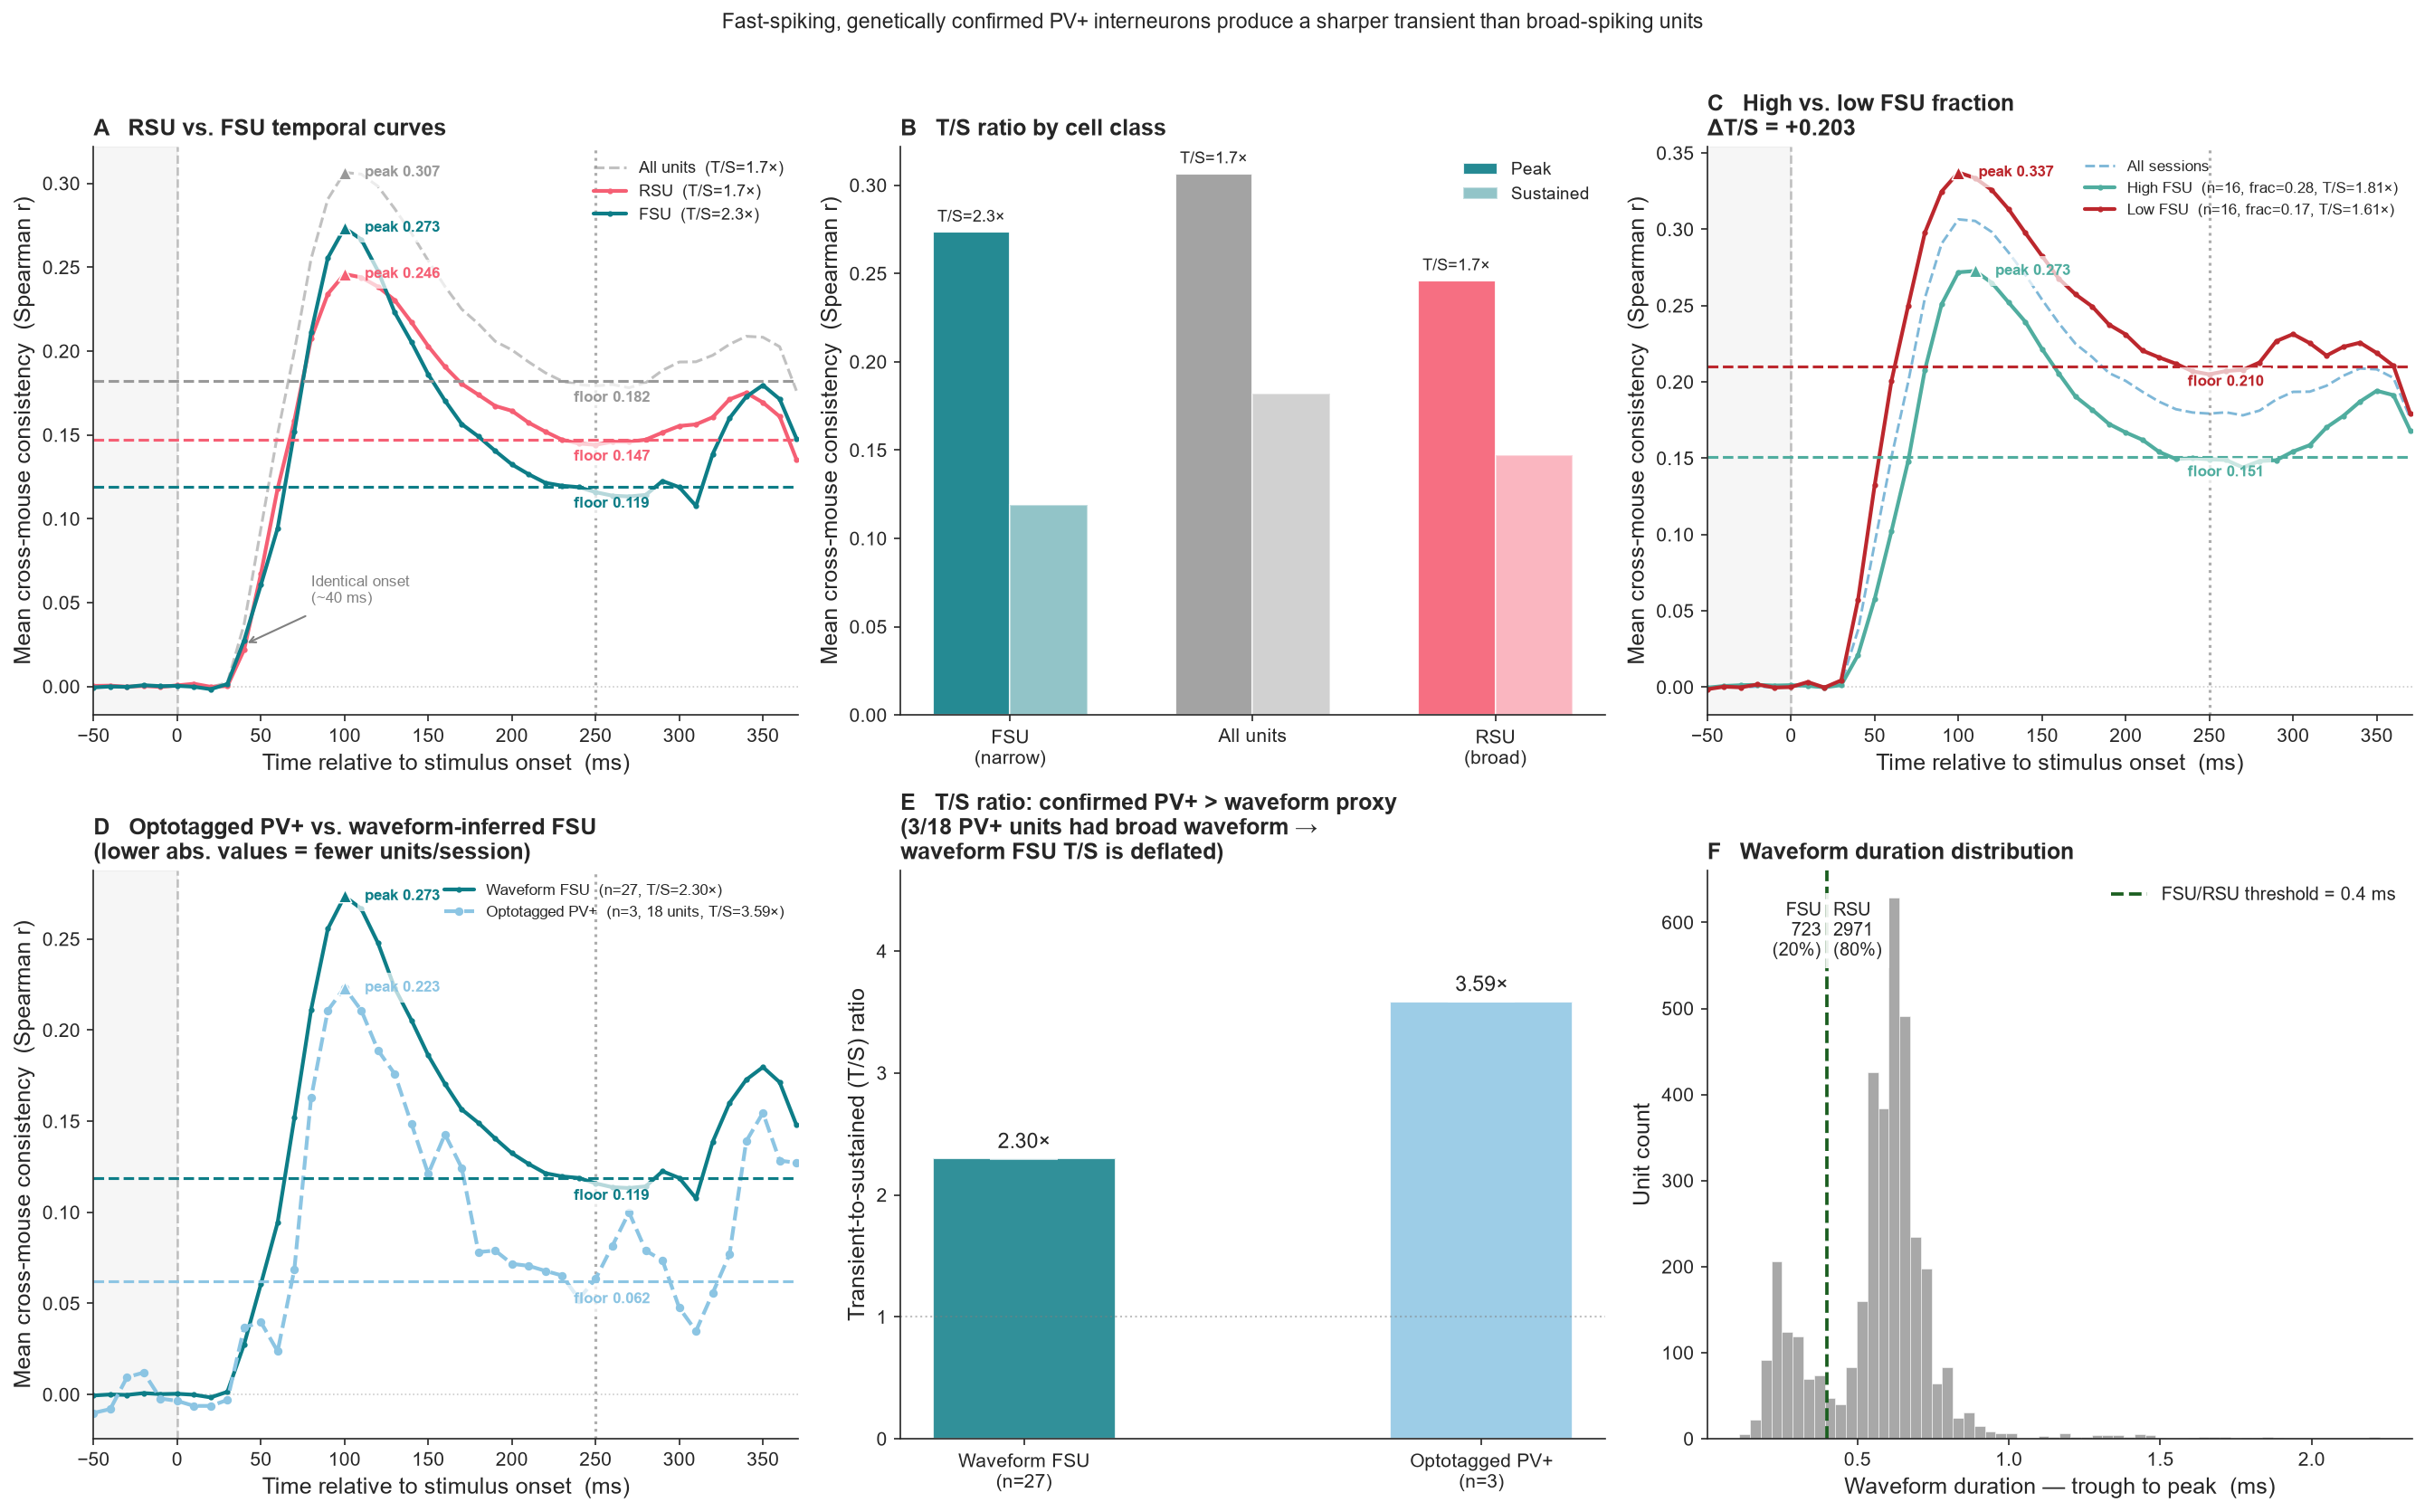

In [9]:
fig = plt.figure(figsize=(18, 11))
ax_curves  = fig.add_subplot(2, 3, 1)
ax_ts_bars = fig.add_subplot(2, 3, 2)
ax_fsu_grp = fig.add_subplot(2, 3, 3)
ax_pv_curve= fig.add_subplot(2, 3, 4)
ax_pv_bars = fig.add_subplot(2, 3, 5)
ax_wf_hist = fig.add_subplot(2, 3, 6)

text_bbox = dict(facecolor='white', alpha=0.7, edgecolor='none')

def setup_time_ax(ax):
    ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
    ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.5, alpha=0.8)
    ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)
    ax.set_xlabel('Time relative to stimulus onset  (ms)')
    ax.set_ylabel('Mean cross-mouse consistency  (Spearman r)')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
    ax.spines[['top', 'right']].set_visible(False)


def mark_peak_floor(ax, t, c, peak, sus, color, rank=0,
                     sustained_lo=SUSTAINED_LO, sustained_hi=SUSTAINED_HI):
    """Mark the peak (max, 0-250 ms) and floor (mean sustained window) of a curve."""
    t = np.asarray(t); c = np.asarray(c)
    post_mask = (t >= 0) & (t <= 250)
    peak_t  = t[post_mask][np.argmax(c[post_mask])]
    floor_t = (sustained_lo + sustained_hi) / 2

    ax.scatter([peak_t], [peak], marker='^', s=48, color=color, zorder=6,
               edgecolor='white', linewidth=0.7)
    ax.text(peak_t + 12, peak,
            f'peak {peak:.3f}',
            fontsize=8, color=color, fontweight='bold',
            ha='left', va='center', bbox=text_bbox)

    ax.hlines(sus, -50, 370,
            colors=color, linewidth=1.5, linestyle='--')
    ax.text(floor_t + 2, sus-0.01,
            f'floor {sus:.3f}',
            fontsize=8, color=color, fontweight='bold',
            ha='left', va='center', bbox=text_bbox)

# ── Panel A: RSU / FSU / all curves ──────────────────────────────────────────
setup_time_ax(ax_curves)
ax_curves.plot(times_ms, mean_c, color=COL_REF, linewidth=1.5, linestyle='--',
               alpha=0.6, label=f'All units  (T/S={ts_ratio_all:.1f}×)')
ax_curves.plot(ts_rsu, mc_rsu, color=COL_RSU, linewidth=2.0,
               marker='o', markersize=2,
               label=f'RSU  (T/S={ts_ratio_rsu:.1f}×)')
ax_curves.plot(ts_fsu, mc_fsu, color=COL_FSU, linewidth=2.0,
               marker='o', markersize=2,
               label=f'FSU  (T/S={ts_ratio_fsu:.1f}×)')
mark_peak_floor(ax_curves, times_ms, mean_c, pk_all, sus_all, COL_REF, rank=0)
mark_peak_floor(ax_curves, ts_rsu,   mc_rsu, pk_rsu, sus_rsu, COL_RSU, rank=1)
mark_peak_floor(ax_curves, ts_fsu,   mc_fsu, pk_fsu, sus_fsu, COL_FSU, rank=2)
# Annotate identical onset
ax_curves.annotate('Identical onset\n(~40 ms)', xy=(40, 0.025),
                   xytext=(80, 0.05),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                   color='gray', fontsize=8, bbox=text_bbox)
ax_curves.legend(frameon=False, fontsize=8.5)
ax_curves.set_title('A   RSU vs. FSU temporal curves', loc='left',
                    fontweight='bold', pad=6)

# ── Panel B: T/S ratio bars ──────────────────────────────────────────────────
classes   = ['FSU', 'All', 'RSU']
pk_vals   = [pk_fsu, pk_all, sus_all + (pk_all-sus_all), pk_rsu]   # placeholder
pk_vals   = [pk_fsu, pk_all, pk_rsu]
sus_vals  = [sus_fsu, sus_all, sus_rsu]
ts_vals   = [ts_ratio_fsu, ts_ratio_all, ts_ratio_rsu]
bar_cols  = [COL_FSU, COL_REF, COL_RSU]
x = np.arange(3)
w = 0.32
ax_ts_bars.bar(x - w/2, pk_vals,  w, color=bar_cols, alpha=0.9, label='Peak')
ax_ts_bars.bar(x + w/2, sus_vals, w, color=bar_cols, alpha=0.45, label='Sustained')
for i, (ts_v, pk_v) in enumerate(zip(ts_vals, pk_vals)):
    ax_ts_bars.text(x[i] - w/2, pk_v + 0.004, f'T/S={ts_v:.1f}×',
                    ha='center', va='bottom', fontsize=8.5, bbox=text_bbox)
ax_ts_bars.set_xticks(x)
ax_ts_bars.set_xticklabels(['FSU\n(narrow)', 'All units', 'RSU\n(broad)'])
ax_ts_bars.set_ylabel('Mean cross-mouse consistency  (Spearman r)')
ax_ts_bars.legend(frameon=False, fontsize=9)
ax_ts_bars.set_title('B   T/S ratio by cell class', loc='left',
                     fontweight='bold', pad=6)
ax_ts_bars.spines[['top', 'right']].set_visible(False)

# ── Panel C: high vs. low FSU fraction ───────────────────────────────────────
setup_time_ax(ax_fsu_grp)
ax_fsu_grp.plot(times_ms, mean_c, color=COL_DATA, linewidth=1.4,
                linestyle='--', alpha=0.5, label='All sessions')
ax_fsu_grp.plot(ts_high, mc_high, color=COL_HIGH_FSU_FRAC, linewidth=2.0,
                marker='o', markersize=2,
                label=f'High FSU  (n={len(high_fsu_sids)}, '
                      f'frac={mean_frac_high:.2f}, T/S={ts_ratio_high:.2f}×)')
ax_fsu_grp.plot(ts_low, mc_low, color=COL_LOW_FSU_FRAC, linewidth=2.0,
                marker='o', markersize=2,
                label=f'Low FSU  (n={len(low_fsu_sids)}, '
                      f'frac={mean_frac_low:.2f}, T/S={ts_ratio_low:.2f}×)')
_, pk_high, sus_high = ts_ratio(mc_high, ts_high)
_, pk_low,  sus_low  = ts_ratio(mc_low,  ts_low)
mark_peak_floor(ax_fsu_grp, ts_high, mc_high, pk_high, sus_high, COL_HIGH_FSU_FRAC, rank=0)
mark_peak_floor(ax_fsu_grp, ts_low,  mc_low,  pk_low,  sus_low,  COL_LOW_FSU_FRAC,          rank=1)
ax_fsu_grp.legend(frameon=False, fontsize=8)
ax_fsu_grp.set_title(f'C   High vs. low FSU fraction\n'
                     f'ΔT/S = +{ts_ratio_high-ts_ratio_low:.3f}',
                     loc='left', fontweight='bold', pad=6)

# ── Panel D: optotagged PV+ vs. waveform FSU ─────────────────────────────────
setup_time_ax(ax_pv_curve)
ax_pv_curve.plot(ts_fsu, mc_fsu, color=COL_FSU, linewidth=2.0,
                 marker='o', markersize=2,
                 label=f'Waveform FSU  (n=27, T/S={ts_ratio_fsu:.2f}×)')
ax_pv_curve.plot(ts_pv, mc_pv, color=COL_FSU_PV, linewidth=2.0,
                 linestyle='--', marker='o', markersize=3.5,
                 label=f'Optotagged PV+  (n={len(usable_pv_sids)}, '
                       f'{total_tagged} units, T/S={ts_ratio_pv:.2f}×)')
mark_peak_floor(ax_pv_curve, ts_fsu, mc_fsu, pk_fsu, sus_fsu, COL_FSU,    rank=0)
mark_peak_floor(ax_pv_curve, ts_pv,  mc_pv,  pk_pv,  sus_pv_val, COL_FSU_PV, rank=1)
ax_pv_curve.legend(frameon=False, fontsize=8)
ax_pv_curve.set_title('D   Optotagged PV+ vs. waveform-inferred FSU\n'
                      '(lower abs. values = fewer units/session)',
                      loc='left', fontweight='bold', pad=6)

# ── Panel E: T/S ratio comparison ────────────────────────────────────────────
labels_pv  = [f'Waveform FSU\n(n=27)', f'Optotagged PV+\n(n={len(usable_pv_sids)})']
ts_pv_vals = [ts_ratio_fsu, ts_ratio_pv]
bars_pv    = ax_pv_bars.bar(labels_pv, ts_pv_vals,
                             color=[COL_FSU, COL_FSU_PV], alpha=0.85, width=0.4)
for bar, v in zip(bars_pv, ts_pv_vals):
    ax_pv_bars.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{v:.2f}×', ha='center', va='bottom', fontsize=11,
                    bbox=text_bbox)
ax_pv_bars.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_pv_bars.set_ylabel('Transient-to-sustained (T/S) ratio')
ax_pv_bars.set_title(f'E   T/S ratio: confirmed PV+ > waveform proxy\n'
                     f'({n_broad_pv}/18 PV+ units had broad waveform →\n'
                     'waveform FSU T/S is deflated)',
                     loc='left', fontweight='bold', pad=6)
finite_ts = [v for v in ts_pv_vals if np.isfinite(v)]
ax_pv_bars.set_ylim(0, (max(finite_ts) if finite_ts else 5.0) * 1.3)
ax_pv_bars.spines[['top', 'right']].set_visible(False)

# ── Panel F: waveform duration histogram ─────────────────────────────────────
wf_vals = visp_wf['waveform_duration'].dropna()
ax_wf_hist.hist(wf_vals, bins=60, color=COL_REF, alpha=0.85,
                edgecolor='white', linewidth=0.3)
ax_wf_hist.axvline(WF_THRESHOLD_MS, color=COL_FIT, linestyle='--', linewidth=1.8,
                   label=f'FSU/RSU threshold = {WF_THRESHOLD_MS} ms')
n_fsu_total = (wf_vals < WF_THRESHOLD_MS).sum()
n_rsu_total = (wf_vals >= WF_THRESHOLD_MS).sum()
ax_wf_hist.text(WF_THRESHOLD_MS - 0.02, ax_wf_hist.get_ylim()[1] * 0.85,
                f'FSU\n{n_fsu_total}\n({n_fsu_total/len(wf_vals)*100:.0f}%)',
                ha='right', fontsize=9.5, bbox=text_bbox)
ax_wf_hist.text(WF_THRESHOLD_MS + 0.02, ax_wf_hist.get_ylim()[1] * 0.85,
                f'RSU\n{n_rsu_total}\n({n_rsu_total/len(wf_vals)*100:.0f}%)',
                ha='left', fontsize=9.5, bbox=text_bbox)
ax_wf_hist.set_xlabel('Waveform duration — trough to peak  (ms)')
ax_wf_hist.set_ylabel('Unit count')
ax_wf_hist.set_title('F   Waveform duration distribution', loc='left',
                     fontweight='bold', pad=6)
ax_wf_hist.legend(frameon=False)
ax_wf_hist.spines[['top', 'right']].set_visible(False)

fig.suptitle('Fast-spiking, genetically confirmed PV+ interneurons produce a sharper '
             'transient than broad-spiking units',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig 5A — RSU vs. FSU temporal curves',
    all_units_times_ms=times_ms,
    all_units_mean_consistency=mean_c,
    rsu_times_ms=ts_rsu,
    rsu_mean_consistency=mc_rsu,
    fsu_times_ms=ts_fsu,
    fsu_mean_consistency=mc_fsu,
)
print_figure_data(
    'Fig 5B — T/S ratio by cell class (FSU, All, RSU)',
    class_labels=classes,
    peak_values=pk_vals,
    sustained_values=sus_vals,
    ts_ratio_values=ts_vals,
)
print_figure_data(
    'Fig 5C — High vs. low FSU-fraction session groups',
    all_sessions_times_ms=times_ms,
    all_sessions_mean_consistency=mean_c,
    high_fsu_times_ms=ts_high,
    high_fsu_mean_consistency=mc_high,
    high_fsu_n_sessions=np.array(len(high_fsu_sids)),
    high_fsu_mean_fraction=np.array(mean_frac_high),
    high_fsu_ts_ratio=np.array(ts_ratio_high),
    low_fsu_times_ms=ts_low,
    low_fsu_mean_consistency=mc_low,
    low_fsu_n_sessions=np.array(len(low_fsu_sids)),
    low_fsu_mean_fraction=np.array(mean_frac_low),
    low_fsu_ts_ratio=np.array(ts_ratio_low),
)
print_figure_data(
    'Fig 5D — Optotagged PV+ vs. waveform-inferred FSU curves',
    waveform_fsu_times_ms=ts_fsu,
    waveform_fsu_mean_consistency=mc_fsu,
    waveform_fsu_ts_ratio=np.array(ts_ratio_fsu),
    optotagged_pv_times_ms=ts_pv,
    optotagged_pv_mean_consistency=mc_pv,
    optotagged_pv_n_sessions=np.array(len(usable_pv_sids)),
    optotagged_pv_n_units=np.array(total_tagged),
    optotagged_pv_ts_ratio=np.array(ts_ratio_pv),
)
print_figure_data(
    'Fig 5E — T/S ratio comparison: waveform FSU vs. optotagged PV+',
    group_labels=labels_pv,
    ts_ratio_values=ts_pv_vals,
    n_broad_waveform_pv_units=np.array(n_broad_pv),
    n_total_optotagged_units=np.array(18),
)
print_figure_data(
    'Fig 5F — Waveform duration distribution and FSU/RSU threshold',
    waveform_duration_ms_all_units=wf_vals.to_numpy(),
    fsu_rsu_threshold_ms=np.array(WF_THRESHOLD_MS),
    n_fsu_total=np.array(n_fsu_total),
    n_rsu_total=np.array(n_rsu_total),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_cell_type_dissociation.png', bbox_inches='tight')
plt.show()


Fig S4A — Optotagged PV+ unit waveform durations by session

--- session_ids ---
[721123822 746083955 760345702 773418906 797828357]

--- waveform_duration_ms ---
[0.20603  0.260972 0.192295 0.20603  0.20603  0.274707 0.247236 0.192295 0.247236 0.233501 0.20603  0.329648 0.20603  0.535678 0.61809  0.576884 0.315913 0.178559]

--- fsu_rsu_threshold_ms ---
0.4

--- n_misclassified_as_rsu ---
3

--- n_total_optotagged ---
18

Fig S4B — Confusion matrix: optotagging vs. waveform class

--- confusion_matrix ---
[[ 15   3]
 [ 43 188]]

--- row_labels ---
['Optotagged PV+' 'Not optotagged']

--- col_labels ---
['FSU' 'RSU']

--- sensitivity_pv_to_fsu ---
0.8333333333333334

--- precision_fsu_to_pv ---
0.25862068965517243


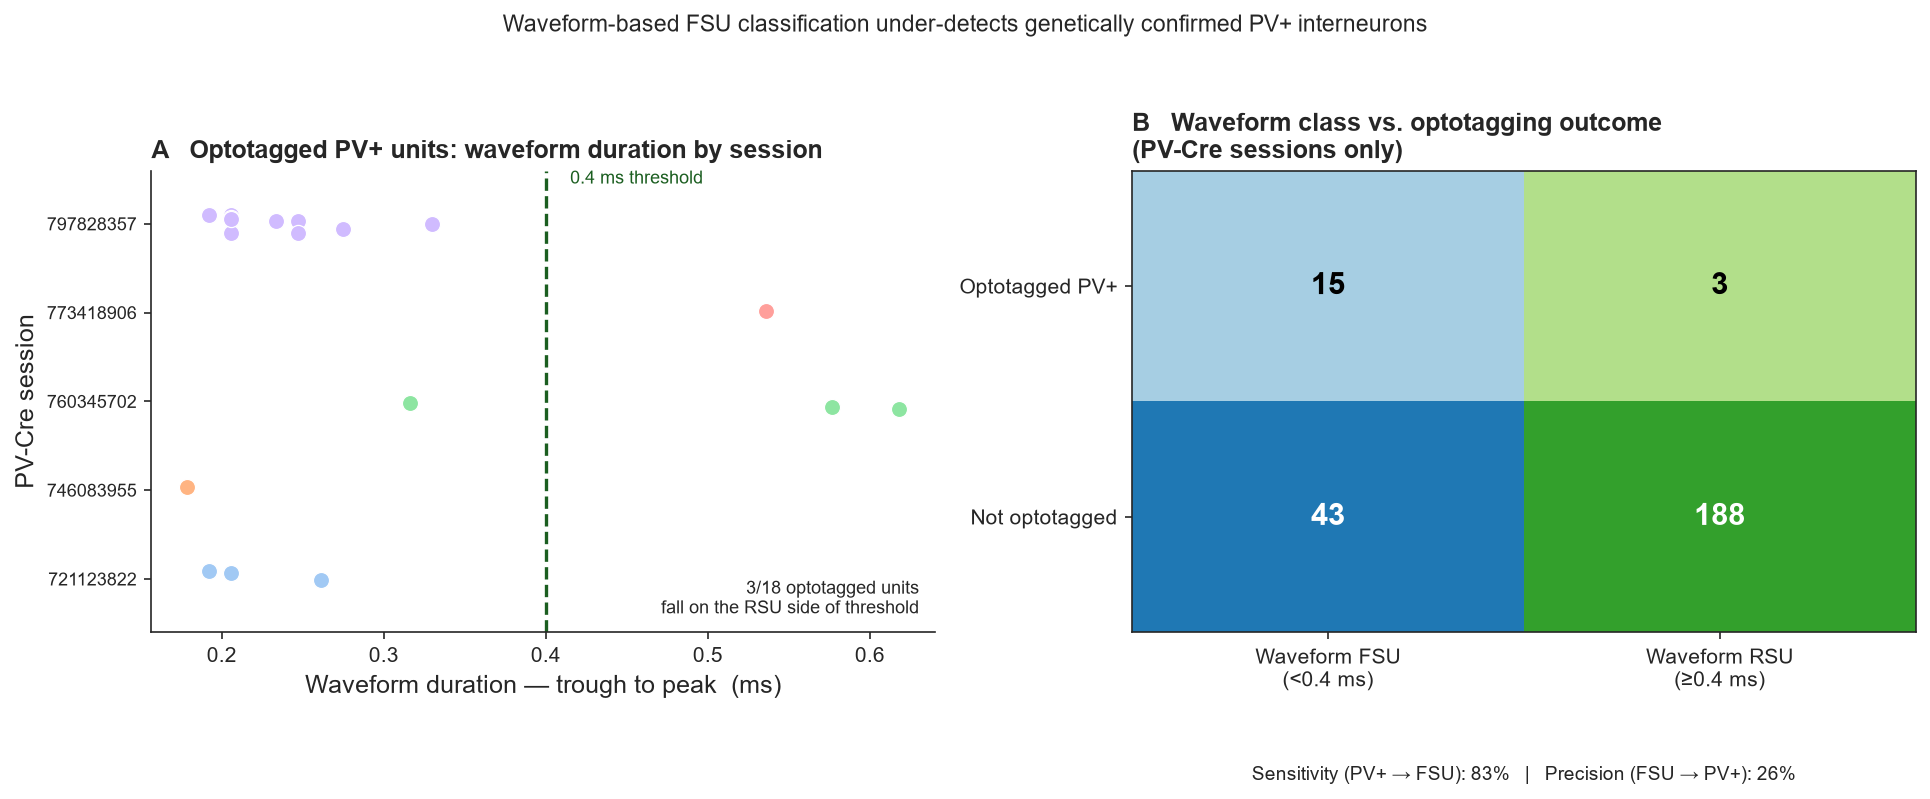

In [10]:
from matplotlib.colors import ListedColormap

fig_s4, (ax_strip, ax_conf) = plt.subplots(1, 2, figsize=(13, 5.5))

# Restrict to PV-Cre sessions, drop units missing waveform duration
pv_wf = pv_units.dropna(subset=['waveform_duration']).copy()
pv_wf['cell_class'] = np.where(pv_wf['waveform_duration'] < WF_THRESHOLD_MS, 'FSU', 'RSU')

session_colors = dict(zip(PV_SESSION_IDS,
                           sns.color_palette('pastel', n_colors=len(PV_SESSION_IDS))))

# ── Panel A: strip plot of optotagged units' waveform duration, one row per session ──
tagged_pv = pv_wf[pv_wf['is_opto']].copy()

for row_i, sid in enumerate(PV_SESSION_IDS):
    sess_tagged = tagged_pv[tagged_pv['ecephys_session_id'] == sid]
    jitter = np.random.default_rng(SEED + row_i).uniform(-0.12, 0.12, size=len(sess_tagged))
    ax_strip.scatter(sess_tagged['waveform_duration'], row_i + jitter,
                      s=60, color=session_colors[sid], edgecolor='white',
                      linewidth=0.6, zorder=3, label=f'{sid} (n={len(sess_tagged)})')

ax_strip.axvline(WF_THRESHOLD_MS, color=COL_FIT, linestyle='--', linewidth=1.6, zorder=2)
ax_strip.text(WF_THRESHOLD_MS + 0.015, len(PV_SESSION_IDS) - 0.4,
              f'{WF_THRESHOLD_MS} ms threshold', color=COL_FIT, fontsize=8.5,
              va='top', bbox=text_bbox)

n_misclassified = (tagged_pv['cell_class'] == 'RSU').sum()
ax_strip.text(0.98, 0.03,
              f'{n_misclassified}/{len(tagged_pv)} optotagged units\nfall on the RSU side of threshold',
              transform=ax_strip.transAxes, ha='right', va='bottom',
              fontsize=8.5, bbox=text_bbox)

ax_strip.set_yticks(range(len(PV_SESSION_IDS)))
ax_strip.set_yticklabels([str(s) for s in PV_SESSION_IDS], fontsize=8.5)
ax_strip.set_xlabel('Waveform duration — trough to peak  (ms)')
ax_strip.set_ylabel('PV-Cre session')
ax_strip.set_title('A   Optotagged PV+ units: waveform duration by session',
                    loc='left', fontweight='bold', pad=6)
ax_strip.spines[['top', 'right']].set_visible(False)
ax_strip.set_ylim(-0.6, len(PV_SESSION_IDS) - 0.4)

# ── Panel B: 2x2 confusion matrix — opto tag vs. waveform class (PV-Cre sessions) ──
conf = pd.crosstab(
    pv_wf['is_opto'].map({True: 'Optotagged PV+', False: 'Not optotagged'}),
    pv_wf['cell_class'],
).reindex(index=['Optotagged PV+', 'Not optotagged'], columns=['FSU', 'RSU'])

cell_ids = np.array([[0, 2], [1, 3]])
cmap4 = ListedColormap(plt.colormaps['Paired'].colors[:4])

im = ax_conf.imshow(cell_ids, cmap=cmap4, aspect='auto', interpolation='nearest',
                    vmin=-0.5, vmax=3.5)

for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        val = conf.values[i, j]
        bg = cmap4(cell_ids[i, j])        
        luminance = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
        txt_color = 'white' if luminance < 0.55 else 'black'
        ax_conf.text(j, i, f'{val}', ha='center', va='center',
                     fontsize=15, fontweight='bold', color=txt_color)

ax_conf.set_xticks([0, 1]); ax_conf.set_xticklabels(['Waveform FSU\n(<0.4 ms)', 'Waveform RSU\n(≥0.4 ms)'])
ax_conf.set_yticks([0, 1]); ax_conf.set_yticklabels(conf.index)
ax_conf.set_title('B   Waveform class vs. optotagging outcome\n(PV-Cre sessions only)',
                   loc='left', fontweight='bold', pad=6)

sensitivity = conf.loc['Optotagged PV+', 'FSU'] / conf.loc['Optotagged PV+'].sum()
fsu_precision = conf.loc['Optotagged PV+', 'FSU'] / conf['FSU'].sum()
ax_conf.text(0.5, -0.32,
             f'Sensitivity (PV+ → FSU): {sensitivity*100:.0f}%   |   '
             f'Precision (FSU → PV+): {fsu_precision*100:.0f}%',
             transform=ax_conf.transAxes, ha='center', fontsize=9, bbox=text_bbox)

fig_s4.suptitle('Waveform-based FSU classification under-detects genetically confirmed PV+ interneurons',
                 fontsize=11, y=1.03)

print_figure_data(
    'Fig S4A — Optotagged PV+ unit waveform durations by session',
    session_ids=np.array(PV_SESSION_IDS),
    waveform_duration_ms=tagged_pv['waveform_duration'].to_numpy(),
    fsu_rsu_threshold_ms=np.array(WF_THRESHOLD_MS),
    n_misclassified_as_rsu=np.array(n_misclassified),
    n_total_optotagged=np.array(len(tagged_pv)),
)
print_figure_data(
    'Fig S4B — Confusion matrix: optotagging vs. waveform class',
    confusion_matrix=conf.values,
    row_labels=np.array(conf.index.tolist()),
    col_labels=np.array(conf.columns.tolist()),
    sensitivity_pv_to_fsu=np.array(sensitivity),
    precision_fsu_to_pv=np.array(fsu_precision),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS4_pv_waveform_confusion.png', bbox_inches='tight')
plt.show()